In [1]:
import udkm1Dsim as ud
import matplotlib.pyplot as plt
import numpy as np
import time

import example_materials.sap as sap_gen
import example_materials.Nb as Nb_gen
import example_materials.TbFe2_110 as TbFe2_110
import example_materials.Al as Al_gen
u=ud.u #import pint units

In [2]:
# import 1TM data for various materials (constants, unit cell, ...)
sap = sap_gen.sap_1TM()
Nb = Nb_gen.Nb_1TM()
TbFe2 = TbFe2_110.TbFe2_110_1TM()
Al = Al_gen.Al_1TM()

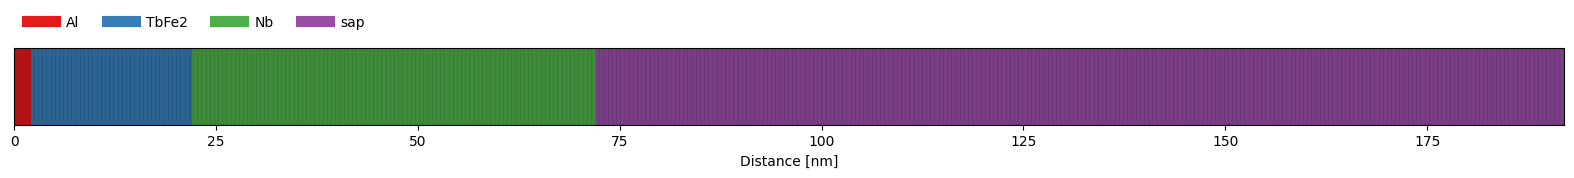

Structure properties:

Name   : TbFe30 Sample
Thickness : 192.0000 nanometer
Roughness : 0.0000 nanometer
----
20 times Al: 2.0000 nanometer
200 times TbFe2: 20.0000 nanometer
500 times Nb: 50.0000 nanometer
1200 times sap: 120.0000 nanometer
----
no substrate



In [3]:
nAl = 20  # in 0.1nm steps
nTbFe2 = 200  # in 0.1nm steps 
nNb = 500  # in 0.1nm steps 
nSap = 1200#  in 0.1nm steps
num_unit_cell = [nAl, nTbFe2, nNb, nSap]


fluenz_sim = [6]*u.mJ/u.cm**2  # Pump Puls Parameter
puls_width = [0.15]*u.ps
pump_delay = [0]*u.ps
multi_abs = True  # absorption: lambert-beer vs. multilayer (better model)
init_temp = 300
heat_diff = True
delays = np.r_[-2:20:0.1]*u.ps  # untersuchte Zeitskala

sample_name = 'TbFe30 Sample'
layers = ['Al', 'TbFe2', 'Nb', 'sap']  # define layers material
sample_dic = {'Al': Al, 'TbFe2': TbFe2, 'Nb': Nb, 'sap': sap}
properties = {'Al': {'C': Al.prop['heat_capacity']},
              'TbFe2': {'C': TbFe2.prop['heat_capacity']},
              'Nb': {'C': Nb.prop['heat_capacity']},
              'sap': {'C': sap.prop['heat_capacity']}}


for l in range(len(layers)):  # add parameters dictionary for the unit cell of each layer
    prop_aml = {}
    prop_aml['a_axis'] = sample_dic[layers[l]].prop['a_axis']
    prop_aml['b_axis'] = sample_dic[layers[l]].prop['b_axis']
    prop_aml['sound_vel'] = sample_dic[layers[l]].prop['sound_vel']
    prop_aml['lin_therm_exp'] = sample_dic[layers[l]].prop['lin_therm_exp']
    prop_aml['heat_capacity'] = sample_dic[layers[l]].prop['heat_capacity']
    prop_aml['therm_cond'] = sample_dic[layers[l]].prop['therm_cond']
    prop_aml['opt_pen_depth'] = sample_dic[layers[l]].prop['opt_pen_depth']
    prop_aml['opt_ref_index'] = sample_dic[layers[l]].prop['opt_ref_index']
    prop_aml['phonon_damping'] = sample_dic[layers[l]].prop['phonon_damping']
    properties[layers[l]]['amorphous_layer'] = ud.AmorphousLayer(
        layers[l], layers[l], 0.1*u.nm, sample_dic[layers[l]].prop['density'], **prop_aml)

S = ud.Structure(sample_name)  # create empty sample (structure)
for l in range(len(layers)):  # add all previously specified layers to the structure
    S.add_sub_structure(properties[layers[l]]['amorphous_layer'], num_unit_cell[l])
S.visualize()  # plot the structure diagram
print(S)  # print structure information

_, _, distances = S.get_distances_of_layers()

In [4]:
''' Determine the optical absorption from the excitation conditions '''

h = ud.Heat(S, True)  # wärme initialisieren, dann anregung simulieren
h.excitation = {'fluence': fluenz_sim, 'delay_pump': pump_delay, 'pulse_width': puls_width, 'backside': False,
                'multilayer_absorption': multi_abs, 'wavelength': 800*u.nm, 'theta': 90*u.deg}

dAdzLB = h.get_Lambert_Beer_absorption_profile()
dAdz, _, _, _ = h.get_multilayers_absorption_profile()

Absorption profile is calculated by Lambert-Beer's law.
Absorption profile is calculated by multilayer formalism.
Total reflectivity of 70.6 % and transmission of 1.1 %.


c:\Users\cwalz\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


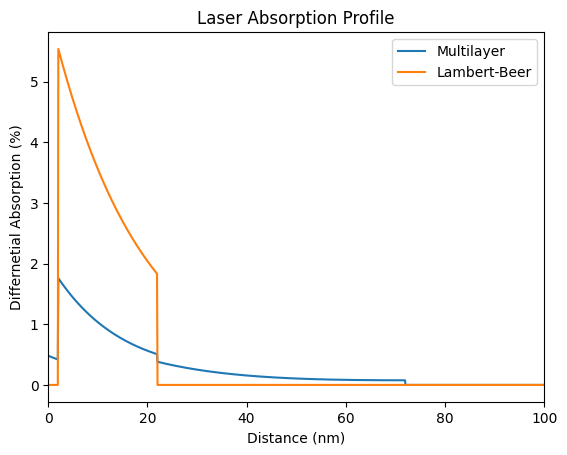

In [5]:
'''Plot the absorption profile'''

plt.figure()
plt.plot(distances.to('nm'), dAdz*1e-9*1e2, label=r'Multilayer')
plt.plot(distances.to('nm'), dAdzLB*1e-9*1e2, label=r'Lambert-Beer')
plt.xlim(0, 100)
plt.legend()
plt.xlabel('Distance (nm)')
plt.ylabel('Differnetial Absorption (%)')
plt.title('Laser Absorption Profile')
plt.show()

In [6]:
''' Get Temperature Map from the absorption profile including heat diffusion '''


h.save_data = False
h.disp_messages = True
# h.ode_options = {'max_step':1e-11}
# h.progress_bar = True
h.heat_diffusion = heat_diff
h.boundary_conditions = {'top_type': 'isolator', 'bottom_type': 'isolator'}

Init_temp = init_temp

print(h)

temp_map, delta_temp_map = h.get_temp_map(delays, Init_temp)

Heat simulation properties:

This is the current structure for the simulations:

Structure properties:

Name   : TbFe30 Sample
Thickness : 192.0000 nanometer
Roughness : 0.0000 nanometer
----
20 times Al: 2.0000 nanometer
200 times TbFe2: 20.0000 nanometer
500 times Nb: 50.0000 nanometer
1200 times sap: 120.0000 nanometer
----
no substrate


Display properties:

================================  =======================================================
                       parameter  value
================================  =======================================================
                    force recalc  True
                 cache directory  ./
                display messages  True
                       save data  False
                    progress bar  True
              excitation fluence  [6.0] mJ/cm²
                excitation delay  [0.0] ps
         excitation pulse length  [0.15] ps
           excitation wavelength  800.0 nm
                excitation theta  90.0 deg
e

0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 35.773221 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 33.444881 s
Elapsed time for _temp_map_: 69.609109 s


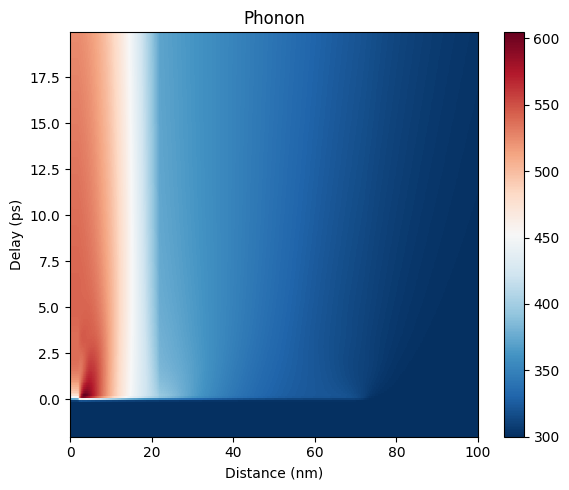

In [7]:
# %% temp maps plotten für e- und ph
plt.figure(figsize=[6, 5])
plt.subplot(1, 1, 1)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :],
               shading='auto', cmap='RdBu_r', vmin=np.min(temp_map[:, :]), vmax=np.max(temp_map[:, :]))
plt.colorbar()
plt.xlim(0, 100)
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Phonon')
plt.tight_layout()
plt.show()

In [8]:
''' Get the picosecond strain dynamics from the Temperature Map '''

pnum = ud.PhononNum(S, True)
pnum.disp_messages = True
# pnum.progress_bar = True
pnum.save_data = False
strain_map = pnum.get_strain_map(delays, temp_map, delta_temp_map)

Calculating linear thermal expansion ...
Calculating coherent dynamics with ODE solver ...


0it [00:00, ?it/s]

Elapsed time for _strain_map_: 1.631471 s


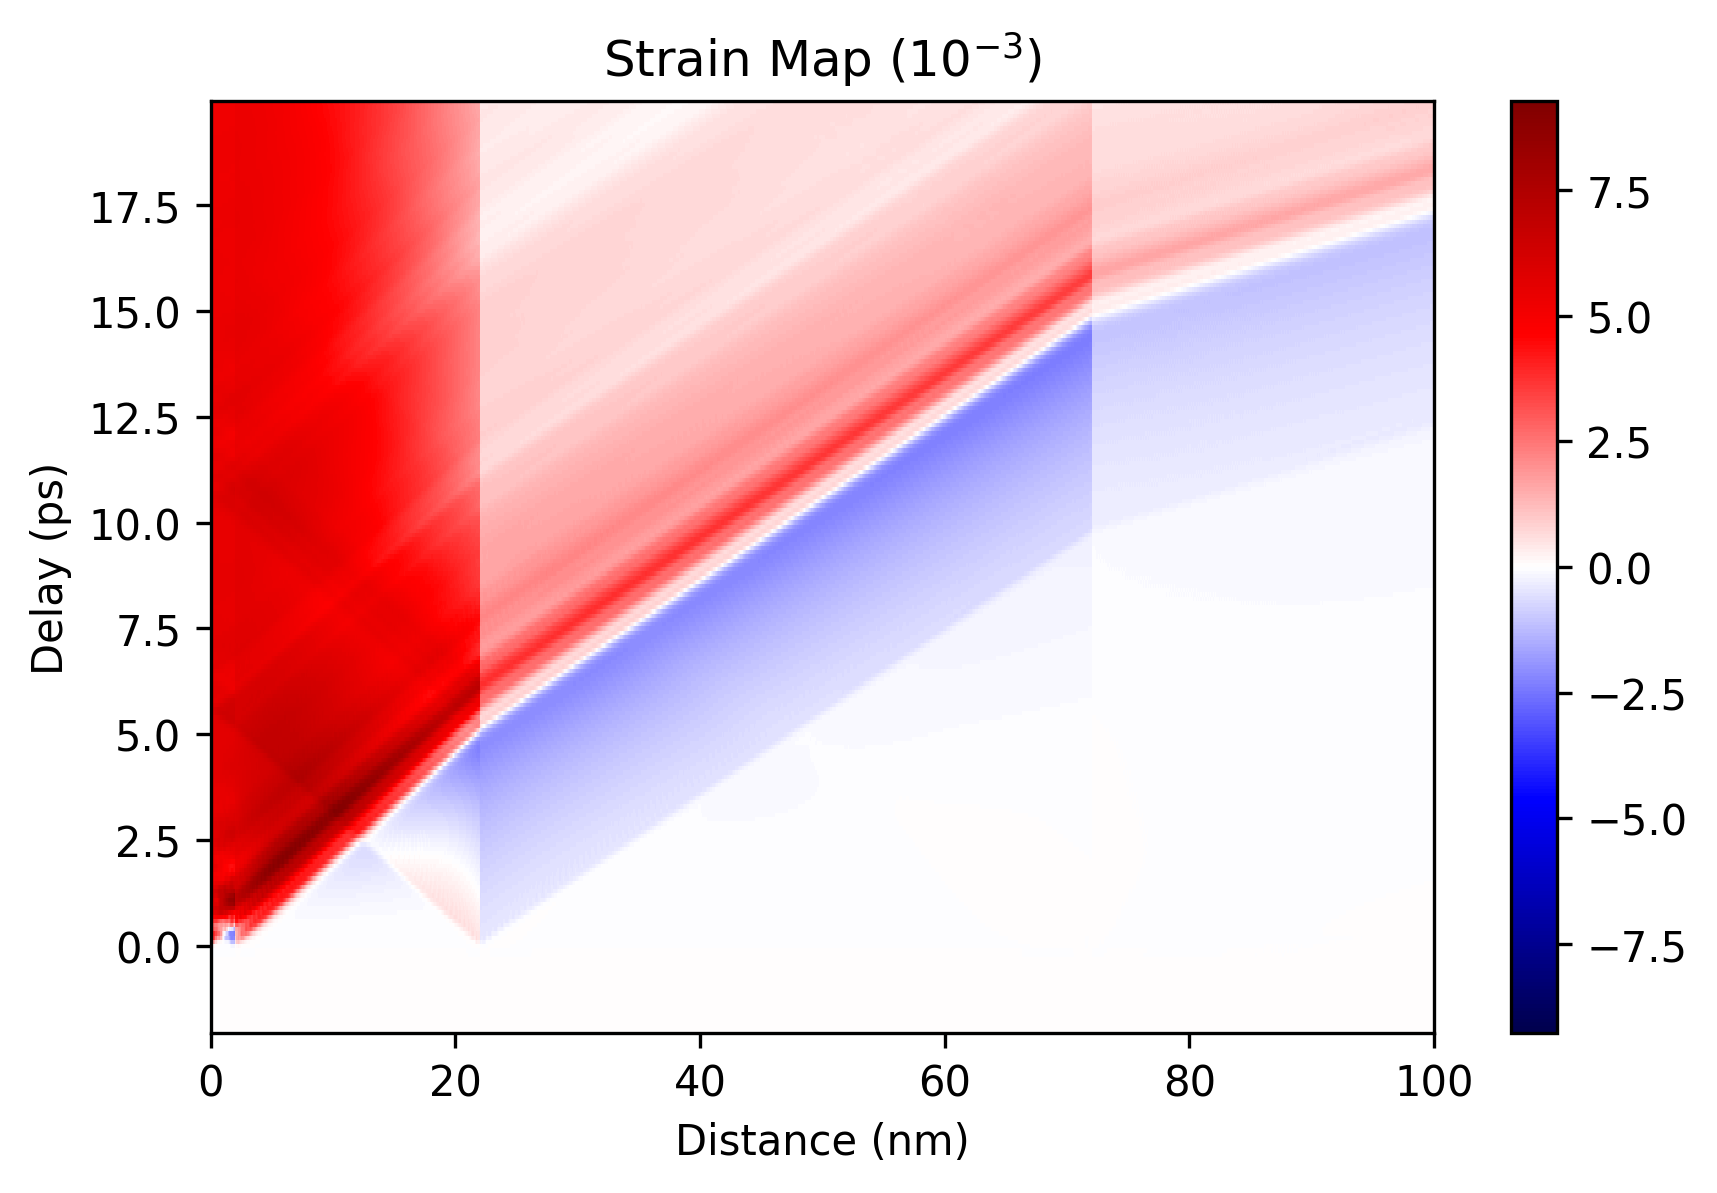

In [ ]:

# %% und plotten
plt.figure(figsize=[6, 5])
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, 1e3*strain_map, shading='auto',
               cmap='seismic', vmin=-1*np.max(1e3*strain_map), vmax=1*np.max(1e3*strain_map))
plt.colorbar()
plt.xlim(0, 100)
# plt.ylim(-2, 0)
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title(r'Strain Map ($10^{-3}$)')
plt.tight_layout()
plt.show()

In [ ]:
ud.helpers.save_to_h5('example_data', delays, distances, S, abs_profile=dAdz, temp_map=temp_map, strain_map=strain_map)

c:\Users\cwalz\AppData\Local\Programs\Python\Python312\Lib\site-packages\h5py\_hl\base.py:118: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data, order="C", dtype=as_dtype)


In [11]:
ud.helpers.read_from_h5('example_data.h5')

(array([5.0000e-11, 1.5000e-10, 2.5000e-10, ..., 1.9165e-07, 1.9175e-07,
        1.9185e-07]),
 array([-2.00000000e-12, -1.90000000e-12, -1.80000000e-12, -1.70000000e-12,
        -1.60000000e-12, -1.50000000e-12, -1.40000000e-12, -1.30000000e-12,
        -1.20000000e-12, -1.10000000e-12, -1.00000000e-12, -9.00000000e-13,
        -8.00000000e-13, -7.00000000e-13, -6.00000000e-13, -5.00000000e-13,
        -4.00000000e-13, -3.00000000e-13, -2.00000000e-13, -1.00000000e-13,
         1.77635684e-27,  1.00000000e-13,  2.00000000e-13,  3.00000000e-13,
         4.00000000e-13,  5.00000000e-13,  6.00000000e-13,  7.00000000e-13,
         8.00000000e-13,  9.00000000e-13,  1.00000000e-12,  1.10000000e-12,
         1.20000000e-12,  1.30000000e-12,  1.40000000e-12,  1.50000000e-12,
         1.60000000e-12,  1.70000000e-12,  1.80000000e-12,  1.90000000e-12,
         2.00000000e-12,  2.10000000e-12,  2.20000000e-12,  2.30000000e-12,
         2.40000000e-12,  2.50000000e-12,  2.60000000e-12,  2.7000000